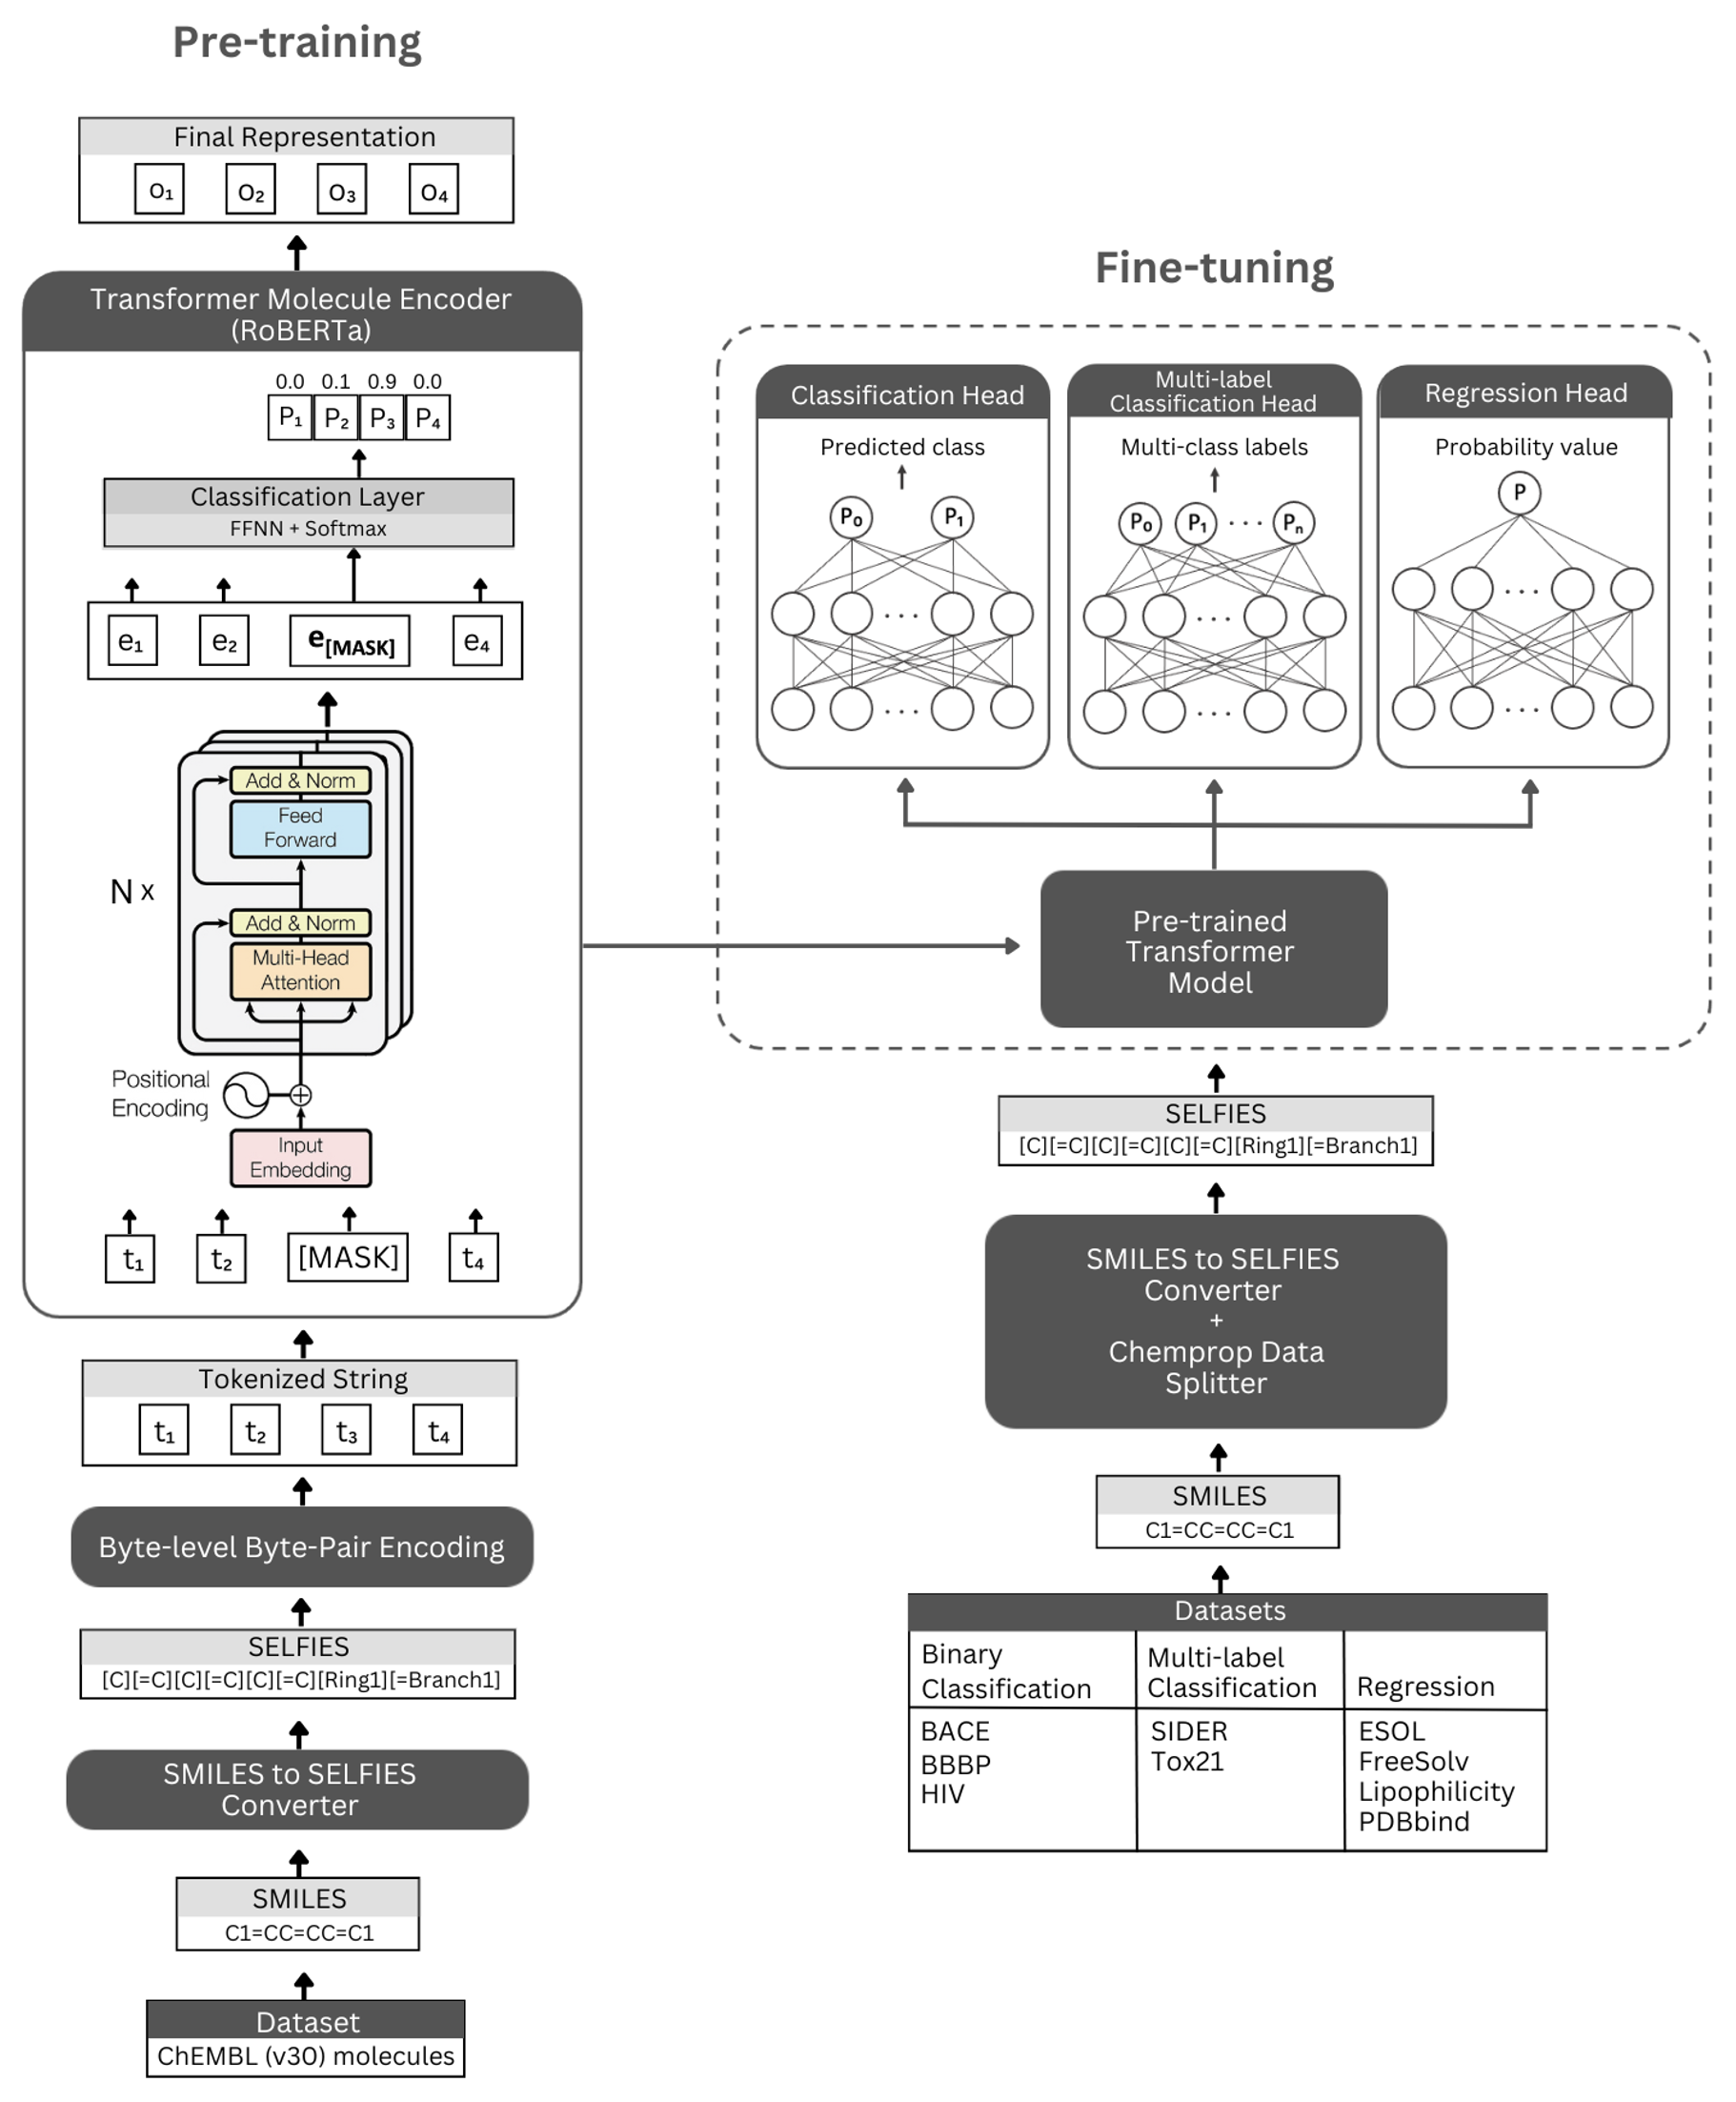

**Fine tuning de roberta**

La head de classification incluse par défaut dans RoBERTa (par exemple avec RobertaForSequenceClassification) est initialisée aléatoirement, et non pré-entraînée. Cela signifie qu’au chargement du modèle de base, seuls les poids du backbone (le cœur du modèle) proviennent du pré-entraînement ; la head est créée avec des poids nouveaux qui doivent impérativement être entraînés sur ta tâche cible.

Les couches du backbone RoBERTa sont pré-entraînées sur des données massives, ce qui donne au modèle une solide connaissance générale du langage

    Le backbone reçoit les poids pré-entraînés grâce au pré-entraînement sur corpus massif.

La head (dense + output) est ajoutée automatiquement, mais ses poids sont aléatoires et inutilisables sans fine-tuning.

Il est donc nécessaire de procéder à un fine-tuning pour rendre la head réellement utile et adaptée à la classification souhaitée.

In [107]:
# Charger le modèle fichier de datas du drive
import pandas as pd
books = pd.read_csv('drive/MyDrive/roberta_books/BooksDataSet.csv')
books = books.drop(['Unnamed: 0'], axis=1)
print(books.head())


    book_id                  book_name    genre  \
0   3248537          Drowned Wednesday  Fantasy   
1  27796919              The Lost Hero  Fantasy   
2   3910776  The Eyes of the Overworld  Fantasy   
3   5969644            Magic's Promise  Fantasy   
4   3173445             Taran Wanderer  Fantasy   

                                             summary  
0   Drowned Wednesday is the first Trustee among ...  
1   As the book opens, Jason awakens on a school ...  
2   Cugel is easily persuaded by the merchant Fia...  
3   The book opens with Herald-Mage Vanyel return...  
4   Taran and Gurgi have returned to Caer Dallben...  


informations sur le dataset

In [108]:
print(books.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   book_id    3000 non-null   int64 
 1   book_name  3000 non-null   object
 2   genre      3000 non-null   object
 3   summary    3000 non-null   object
dtypes: int64(1), object(3)
memory usage: 93.9+ KB
None


nombre de genres du dataset

In [109]:
print(books['genre'].value_counts())
genre_counts = books['genre'].value_counts()

genre
Fantasy             500
Science Fiction     500
Crime Fiction       500
Historical novel    500
Horror              500
Thriller            500
Name: count, dtype: int64


affichage des ratio de genres de livres dans un camembert

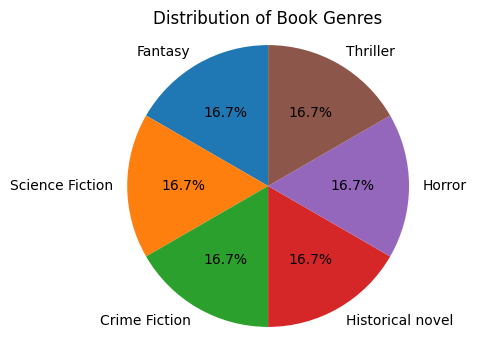

In [110]:

import matplotlib.pyplot as plt
# Assuming 'genre' column exists in the 'books' DataFrame
genre_counts = books['genre'].value_counts()
# Create the pie chart
plt.figure(figsize=(4, 4)) # Adjust figure size as needed
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Book Genres')
plt.axis('equal') # Equal aspect ratio ensures that the pie chart is circular
plt.show()


affichage des ratio de genres de livres dans un diagramme en barres

/tmp/ipython-input-1254838737.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=books, x='genre', order=books['genre'].value_counts().index, palette='viridis')


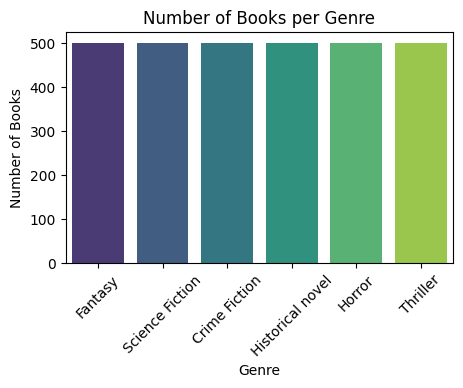

In [111]:
import seaborn as sns
plt.figure(figsize=(5, 3))
sns.countplot(data=books, x='genre', order=books['genre'].value_counts().index, palette='viridis')
plt.title('Number of Books per Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.show()

Retirer les caracteres et symboles spéciaux et mettre en minuscules

In [112]:
print(" avant -------------------------------")
print(books['summary'].iloc[1])
import re
def clean_text(text):
    # Remove special symbols and convert text to lowercase in one step
    text = re.sub(r"[^a-zA-Z\s]", "", text).lower()
    # Remove extra whitespaces
    text = ' '.join(text.split())
    return text

books['summary2']= books['summary']
books['summary2'] = books['summary2'].apply(clean_text)
print(" après -------------------------------")
print(books['summary2'].iloc[1])

 avant -------------------------------
 As the book opens, Jason awakens on a school bus, unable to remember who or where he is, or anything about his past. He is sitting next to Piper McLean and Leo Valdez, who call him by name and say they are his girlfriend and best friend respectively. All three are part of a class field trip to the Grand Canyon, and after they arrive, a classmate Dylan turns into a Venti (Storm Spirit) and attacks the trio and their trip leader, Coach Gleeson Hedge. In the ensuing fight, Jason surprises everyone, including himself, when one of his coins turns into a sword which he uses to battle the storm spirits. Coach Hedge, who reveals himself to be a satyr during the fight, is taken captive by a fleeing spirit. After the battle, a flying chariot arrives to rescue the trio, but one of the people in it, Annabeth, is upset when she discovers that her missing boyfriend, Percy Jackson, is not there as she expected. Annabeth, seeking Percy, was told in a vision from

In [113]:
print(books['summary'].iloc[1])

 As the book opens, Jason awakens on a school bus, unable to remember who or where he is, or anything about his past. He is sitting next to Piper McLean and Leo Valdez, who call him by name and say they are his girlfriend and best friend respectively. All three are part of a class field trip to the Grand Canyon, and after they arrive, a classmate Dylan turns into a Venti (Storm Spirit) and attacks the trio and their trip leader, Coach Gleeson Hedge. In the ensuing fight, Jason surprises everyone, including himself, when one of his coins turns into a sword which he uses to battle the storm spirits. Coach Hedge, who reveals himself to be a satyr during the fight, is taken captive by a fleeing spirit. After the battle, a flying chariot arrives to rescue the trio, but one of the people in it, Annabeth, is upset when she discovers that her missing boyfriend, Percy Jackson, is not there as she expected. Annabeth, seeking Percy, was told in a vision from the goddess Hera to look there for the

Supression des "stopwords" anglais ( les mots ou termes inutiles a la compréhension )

In [114]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
# Set of English stopwords
stop_words = set(stopwords.words('english'))
# Function to remove stopwords

print("Stop words:", stop_words)
print("Number of stop words:", len(stop_words))
print("\n")

print("Example avec le numero 3 ***********************")
print("   --------------------avant suppression des stop_words--------------------------")

print(books['summary2'].iloc[3])
print("  ************************************************")
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])
    # Apply the function to the 'summary' column
books['summary2'] = books['summary2'].apply(remove_stopwords)#remmove stopwords from the 'summary' column
print("  --------------------apres suppression des stop_words-----------------")
print("\n")
print(books['summary2'].iloc[3])
print("  ************************************************")

Stop words: {'just', 'can', "you'd", "they're", 'been', "doesn't", 'herself', 've', 'hasn', 'haven', 'here', 'mightn', 'we', "he'd", 'shouldn', 'same', 'that', 't', "we'd", "don't", 'ours', 'such', 'be', 'our', "i'm", 'no', 'with', "that'll", 'when', 'about', 'down', 'to', 'what', 'before', 'any', 'above', 'between', "i've", 'very', 'my', 'now', "we've", 'which', 'not', 'so', 'at', 'but', 'each', 'whom', "they'd", "they'll", "aren't", 'during', 'further', 'on', "it'd", 'she', "should've", 'then', "you're", 'this', 'am', 'an', 'is', 'isn', "needn't", 'was', "wasn't", "won't", 'up', 'from', "wouldn't", 'has', 'as', 'there', "shouldn't", 'the', 'after', 'for', "he'll", 'doesn', "she'd", "hadn't", 'how', 'into', 'aren', "weren't", 's', 'he', 'myself', 'where', "haven't", 'm', "it's", 'ma', 'all', 'while', 'you', "i'll", 'only', "couldn't", 'i', 'nor', 'or', 'mustn', 'once', "they've", 'd', 'does', 'do', 'theirs', 'they', 'too', "it'll", 'until', 'didn', 'both', 'them', 'his', 'a', 'her', '

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [115]:
print(books['summary'].iloc[3])

 The book opens with Herald-Mage Vanyel returning to his country Valdemar from an extensive campaign along the border with Karse, the neighboring enemy country. He checks in with Valdemar's King Randale and his lifebonded mate, Shavri, and their daughter Jisa. Only a select few know that Jisa is Vanyel's daughter. Because King Randale is sterile, he had asked Vanyel to father an heir. Now, Shavri confides in Vanyel her fear that Randale is mortally ill. Vanyel and his mentor Savil return to Vanyel's family home at Forst Reach, where they find little rest or peace. His parents both try to change his mind about being shay'a'chern, or homosexual. Vanyel becomes somewhat confused about his own sexuality. He wonders if he is truly in love with Shavri. Yfandes, Vanyel's Companion, doesn't buy it and finds the situation amusing. Vanyel also meets his illegitimate nephew, Medren. Medren is small for his age as Vanyel was, and like him it appears that he is often bullied by the armsmaster Jervi

stemming et tokenization (cad reduire chaque mot a leur racine )

In [116]:
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
stemmer = PorterStemmer()# Initialize the Porter Stemmer

print(" avant  tokenization et stemming : ***********************")
print(books['summary2'].iloc[3])

# Function to stem text

word= word_tokenize(books['summary2'].iloc[3])
stemmed_word = [stemmer.stem(word) for word in word]
print(" apres tokenization puis stemming : ***********************")
print(stemmed_word)
print("\n")


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


 avant  tokenization et stemming : ***********************
book opens heraldmage vanyel returning country valdemar extensive campaign along border karse neighboring enemy country checks valdemars king randale lifebonded mate shavri daughter jisa select know jisa vanyels daughter king randale sterile asked vanyel father heir shavri confides vanyel fear randale mortally ill vanyel mentor savil return vanyels family home forst reach find little rest peace parents try change mind shayachern homosexual vanyel becomes somewhat confused sexuality wonders truly love shavri yfandes vanyels companion doesnt buy finds situation amusing vanyel also meets illegitimate nephew medren medren small age vanyel like appears often bullied armsmaster jervis boy powerful bardic gift vanyel sponsors bardic collegium vanyel confronts jervis learns armsmaster intentionally rough also apologizes beating vanyel long ago explains difficult position vanyels father also mentions knew vanyel shayachern beginning als



---



---



Creation d'un classe

In [117]:


import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import pandas as pd
# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('omw-1.4', quiet=True)

'''Ce code Python définit une classe TextStemmer qui permet de traiter efficacement
des textes en anglais : il réalise le "stemming" (réduction des mots à leur racine)
 et peut aussi supprimer les mots vides (stopwords).'''
class TextStemmer:
    def __init__(self, remove_stopwords=False):
        """
        Initialize stemmer with optional stopword removal.
        Args:
        remove_stopwords (bool): Whether to remove stopwords during processing
        """
        self.stemmer = PorterStemmer()# Initialize the Porter Stemmer
        self.stem_cache = {}
        self.remove_stopwords = remove_stopwords
        if remove_stopwords:
            self.stop_words = set(stopwords.words('english'))

    def stem_text(self, text):
        """
        Stem text efficiently using caching and optimized string joining.
        Args:
        text (str): Input text to stem
        Returns:
        str: Stemmed text
        """
        if not isinstance(text, str):
            return ""
        # Tokenize and convert to lowercase once
        words = word_tokenize(text.lower())
        # Filter stopwords if enabled
        if self.remove_stopwords:
            words = [word for word in words if word not in self.stop_words]
        # Use list comprehension with cache lookup for stemming
        stemmed_words = [
            self.stem_cache.setdefault(word, self.stemmer.stem(word))
            for word in words
        ]
        # Join words efficiently
        return ' '.join(stemmed_words)
    def process_dataframe(self, df, column):
        """
        Process an entire dataframe column efficiently.
        Args:
        df (pd.DataFrame): Input dataframe
        column (str): Column name to process
        Returns:
        pd.Series: Series with stemmed text
        """
        return df[column].astype(str).apply(self.stem_text)
    def get_example(self, df, column, index):
        """
        Get a specific example from the processed dataframe.
        Args:
        df (pd.DataFrame): Input dataframe
        column (str): Column name
        index (int): Row index
        Returns:
        str: Processed text at specified index
        """
        return df[column].iloc[index]

Instanciation et utilisation

In [118]:
books_old = books.copy()  # Keep a copy of the original DataFrame

stemmer_instance = TextStemmer(remove_stopwords=True) # Initialize with stopword removal
print(f" avant stemming: {books['summary2'].iloc[3]}")
print(books['summary2'].iloc[3])
# Process the entire dataframe
books['summary2'] = stemmer_instance.process_dataframe(books, 'summary2')
# Get specific example
print("-----------------------------------------------------------------")
print(f" apres stemming: {books['summary2'].iloc[3]}")



 avant stemming: book opens heraldmage vanyel returning country valdemar extensive campaign along border karse neighboring enemy country checks valdemars king randale lifebonded mate shavri daughter jisa select know jisa vanyels daughter king randale sterile asked vanyel father heir shavri confides vanyel fear randale mortally ill vanyel mentor savil return vanyels family home forst reach find little rest peace parents try change mind shayachern homosexual vanyel becomes somewhat confused sexuality wonders truly love shavri yfandes vanyels companion doesnt buy finds situation amusing vanyel also meets illegitimate nephew medren medren small age vanyel like appears often bullied armsmaster jervis boy powerful bardic gift vanyel sponsors bardic collegium vanyel confronts jervis learns armsmaster intentionally rough also apologizes beating vanyel long ago explains difficult position vanyels father also mentions knew vanyel shayachern beginning also knew army service gay keep men courageou

In [119]:
print(f"Original: {books['summary'].iloc[3]}")

Original:  The book opens with Herald-Mage Vanyel returning to his country Valdemar from an extensive campaign along the border with Karse, the neighboring enemy country. He checks in with Valdemar's King Randale and his lifebonded mate, Shavri, and their daughter Jisa. Only a select few know that Jisa is Vanyel's daughter. Because King Randale is sterile, he had asked Vanyel to father an heir. Now, Shavri confides in Vanyel her fear that Randale is mortally ill. Vanyel and his mentor Savil return to Vanyel's family home at Forst Reach, where they find little rest or peace. His parents both try to change his mind about being shay'a'chern, or homosexual. Vanyel becomes somewhat confused about his own sexuality. He wonders if he is truly in love with Shavri. Yfandes, Vanyel's Companion, doesn't buy it and finds the situation amusing. Vanyel also meets his illegitimate nephew, Medren. Medren is small for his age as Vanyel was, and like him it appears that he is often bullied by the armsma

application a la ligne 10

In [120]:

print(books_old['summary2'].iloc[10])

example = stemmer_instance.get_example(books, 'summary2', 10)
print(f"Processed example: \n{example}")

rhys mason former monk majere begins novel trying escape death knight auseric krell rhys retrieved soul dark knight ariakan imprisoned chemosh khas piece hands piece zeboim sends rhys nightshade back solace sheriff gerard seeks others counsel mounting beloved situation rhys agrees gerard stay solace help way possible encounter beloved rhys nightshade atta rhys dog head creature eventually ending new port rhys finally finds brother lleu beloved introduced first dark disciple novel tracking ever since elsewhere mina imprisoned new tower magic istar bottom blood sea newly erected dark god magic nuitari conclave wizards meeting nuitari reveals cousins tower three agree erect three towers high sorcery one back tower mina begins task set chemosh searching solia febalas hall sacrilege found unable take anything chemosh becomes overwhelmed godpresence hall finally nuitari returns gives mina zeboim begun assault upon tower zeboim takes mina first new port rhys brother meet mina vision rhys insi

Convertion du genre en numerique

In [121]:

print(books.head())


    book_id                  book_name    genre  \
0   3248537          Drowned Wednesday  Fantasy   
1  27796919              The Lost Hero  Fantasy   
2   3910776  The Eyes of the Overworld  Fantasy   
3   5969644            Magic's Promise  Fantasy   
4   3173445             Taran Wanderer  Fantasy   

                                             summary  \
0   Drowned Wednesday is the first Trustee among ...   
1   As the book opens, Jason awakens on a school ...   
2   Cugel is easily persuaded by the merchant Fia...   
3   The book opens with Herald-Mage Vanyel return...   
4   Taran and Gurgi have returned to Caer Dallben...   

                                            summary2  
0  drown wednesday first truste among morrow day ...  
1  book open jason awaken school bu unabl rememb ...  
2  cugel easili persuad merchant fianosth attempt...  
3  book open heraldmag vanyel return countri vald...  
4  taran gurgi return caer dallben follow event t...  


In [122]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

books['genre_encoded_txt'] = label_encoder.fit_transform(books['genre'])

Vectorization

In [123]:

# Import necessary libraries for text vectorization
from sklearn.feature_extraction.text import CountVectorizer
#la vecteur de mots (bag of words) est une representation des textes

count_vec = CountVectorizer(max_df=0.90,min_df=2,
                            max_features=1000,stop_words='english')
bagofword_vec = count_vec.fit_transform(books['summary2'])
print(bagofword_vec)


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 242265 stored elements and shape (3000, 1000)>
  Coords	Values
  (0, 272)	3
  (0, 226)	2
  (0, 58)	28
  (0, 980)	2
  (0, 50)	1
  (0, 863)	1
  (0, 104)	1
  (0, 89)	2
  (0, 952)	1
  (0, 258)	1
  (0, 453)	1
  (0, 782)	1
  (0, 16)	1
  (0, 413)	2
  (0, 219)	2
  (0, 67)	2
  (0, 296)	2
  (0, 911)	1
  (0, 862)	1
  (0, 751)	1
  (0, 86)	2
  (0, 964)	1
  (0, 917)	1
  (0, 771)	4
  (0, 417)	3
  :	:
  (2999, 277)	1
  (2999, 285)	1
  (2999, 23)	3
  (2999, 801)	2
  (2999, 860)	1
  (2999, 395)	2
  (2999, 823)	1
  (2999, 649)	9
  (2999, 374)	1
  (2999, 493)	1
  (2999, 149)	1
  (2999, 689)	1
  (2999, 400)	10
  (2999, 720)	2
  (2999, 612)	1
  (2999, 732)	2
  (2999, 6)	1
  (2999, 302)	1
  (2999, 840)	1
  (2999, 476)	1
  (2999, 798)	1
  (2999, 330)	2
  (2999, 501)	9
  (2999, 548)	2
  (2999, 449)	1


In [124]:
#afficher le dictionnaire des mots
print("Dictionnaire des mots (vocabulaire):", count_vec.get_feature_names_out())

Dictionnaire des mots (vocabulaire): ['abandon' 'abil' 'abl' 'aboard' 'abus' 'accept' 'accid' 'accident'
 'accompani' 'accus' 'act' 'action' 'activ' 'actual' 'adam' 'admir'
 'admit' 'adopt' 'advanc' 'adventur' 'affair' 'afterward' 'age' 'agent'
 'ago' 'agre' 'aid' 'air' 'alex' 'alien' 'aliv' 'alli' 'allianc' 'allow'
 'alon' 'alreadi' 'alway' 'america' 'american' 'ancient' 'angel' 'anim'
 'anita' 'ann' 'anoth' 'answer' 'anyon' 'anyth' 'apart' 'appar' 'appear'
 'approach' 'area' 'arm' 'armi' 'arrang' 'arrest' 'arriv' 'arthur' 'ask'
 'assassin' 'assault' 'assign' 'assist' 'associ' 'assum' 'attack'
 'attempt' 'attend' 'attent' 'attract' 'aubrey' 'aunt' 'author' 'avoid'
 'awaken' 'away' 'babi' 'band' 'bank' 'base' 'battl' 'bear' 'beat'
 'beauti' 'becam' 'becom' 'bed' 'befriend' 'begin' 'believ' 'ben' 'best'
 'betray' 'better' 'big' 'billi' 'birth' 'black' 'blood' 'board' 'boat'
 'bodi' 'bomb' 'book' 'born' 'bourn' 'box' 'boy' 'break' 'brief' 'bring'
 'british' 'broken' 'brother' 'brought' '

In [125]:
#afficher le 3eme mot du dictionnaire
print("3eme mot du dictionnaire:", count_vec.get_feature_names_out()[5])

3eme mot du dictionnaire: accept


In [126]:
# Convert the sparse matrix to a dense format
bagofword_vec2 = bagofword_vec.toarray()
print("Shape of the bag-of-words vector:", bagofword_vec2.shape)
print("First 5 rows of the bag-of-words vector:\n", bagofword_vec2[:5])

Shape of the bag-of-words vector: (3000, 1000)
First 5 rows of the bag-of-words vector:
 [[0 0 2 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 3 0]
 [0 0 1 ... 0 0 0]]




---



---



Création de la classe BookDataset

Le DataLoader de PyTorch va appeler __getitem__ automatiquement pour créer chaque batch, transformant chaque texte en données numériques parfaitement préparées pour le modèle

In [127]:
import os
# os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
import torch # PyTorch is a deep learning framework
from transformers import RobertaTokenizer, RobertaForSequenceClassification,RobertaConfig

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
from tqdm import tqdm



# Custom Dataset class
class BookDataset(Dataset):#hérite de torch.utils.data.Dataset
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length#longueur maximale des séquences de tokens
        print(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])#récupère le résumé du livre à l'index idx et le convertit en chaîne de caractères
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,#dans le cas du code présenté (classification de résumés de livres avec RoBERTa), il ne s’agit que de padding masks
            return_tensors='pt'# 'pt' indique que les tenseurs retournés doivent être au format PyTorch
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }



Création des fonctions pour l'entraînement  

In [128]:

def train_epoch(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0



    for batch in tqdm(data_loader, desc="Training"):
        #tqdm est une bibliothèque Python qui affiche une barre de progression pour toute boucle, ce qui permet de visualiser en temps réel l’avancement du traitement
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        #.to(device) permet d’utiliser ce masque avec RoBERTa en accélérant les calculs sur GPU si disponible

        labels = batch['labels'].to(device)

        optimizer.zero_grad()# Remise à zéro des gradients avant la rétropropagation
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        # Forward pass pour obtenir les sorties du modèle

        loss = outputs.loss# Calcul de la perte (loss)
        total_loss += loss.item()# Accumulation de la perte totale

        loss.backward()# Rétropropagation pour calculer les gradients
        optimizer.step()#Mise à jour des poids du modèle

    return total_loss / len(data_loader)# Retourne la perte moyenne sur l’ensemble des batches


Fonction d'evaluation du modèle pour le jeu de test

In [129]:

def evaluate(model, data_loader, device):#évaluation du modèle sur un ensemble de données de test
    model.eval()# Met le modèle en mode évaluation
    predictions = []
    actual_labels = []

    with torch.no_grad():
        # Désactive le calcul des gradients pour économiser de la mémoire et accélérer les calculs (on est en evaluation)
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            #.to(device) permet d’utiliser ce masque avec RoBERTa en accélérant les calculs sur GPU si disponible

            attention_mask = batch['attention_mask'].to(device)
            #.to(device) permet d’utiliser ce masque avec RoBERTa en accélérant les calculs sur GPU si disponible

            labels = batch['labels']
            #labels ne sont pas déplacées sur le device car elles sont utilisées pour le calcul de l’accuracy uniquement

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            # Forward pass pour obtenir les sorties du modèle
            _, preds = torch.max(outputs.logits, dim=1)
            #torch.max renvoie la valeur maximale et son index le long d’une dimension spécifiée (ici dim=1, c’est-à-dire pour chaque ligne)


            predictions.extend(preds.cpu().numpy())
            # Déplace les prédictions sur le CPU et les convertit en tableau numpy avant de les ajouter à la liste des prédictions

            actual_labels.extend(labels.cpu().numpy())
            # Déplace les labels sur le CPU et les convertit en tableau numpy avant de les ajouter à la liste des labels réels


    return accuracy_score(actual_labels, predictions)
    # Calcule et retourne l’accuracy en comparant les labels réels aux prédictions





---



le byte-level BPE employé par RoBERTa permet une tokenisation plus universelle, robuste et efficace, adaptée aux données réelles et multilingues, tout en éliminant le problème des tokens inconnus.

Le byte-level Byte-Pair Encoding (BPE) est la méthode de tokenisation utilisée par RoBERTa, qui traite le texte directement au niveau des bytes (octets), plutôt qu’au niveau des caractères ou des mots.

En résumé, byte-level BPE assure le clean, la tokenisation et l’encodage en une seule étape, dès que le texte brut est donné au tokenizer RoBERTa.

Programme principal

In [130]:
def train_roberta_classifier(books, num_epochs , batch_size ):
    # Prepare data
    X_train, X_test, y_train, y_test = train_test_split(
        books['summary'].values, #books['summary2'] si on desire utiliser les token mais c'est inutile....et moins bon
        books['genre_encoded_txt'].values,
        test_size=0.2,
        random_state=42
    )

    # Initialize tokenizer
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

    print(" nb de classe",len(label_encoder.classes_))

    # Create datasets
    train_dataset = BookDataset(X_train, y_train, tokenizer)
    test_dataset = BookDataset(X_test, y_test, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Initialize model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    config = RobertaConfig.from_pretrained(   'roberta-base',    num_labels=len(label_encoder.classes_),
                                             classifier_dropout=0.2  )
    model = RobertaForSequenceClassification.from_pretrained(   'roberta-base',    config=config).to(device)

    # Initialize optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

    # Training loop
    best_accuracy = 0.7

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        avg_loss = train_epoch(model, train_loader, optimizer, device)
        accuracy = evaluate(model, test_loader, device)

        print(f"Average loss: {avg_loss:.4f}")
        print(f"Accuracy: {accuracy:.4f}")
        valeur=int(accuracy)
        if accuracy > best_accuracy and epoch > 5:#on suppose qu'il faut au moins 5 epochs
            best_accuracy = accuracy
            print(f"Best accuracy achieved: {best_accuracy:.4f}")
            valeur =round(accuracy,2)

            nom_fichier='drive/MyDrive/roberta_books/roberta_book_genre_classifier_'+str(valeur)+'_'+str(num_epochs)+'_'+str(batch_size)+'.pth'
            print(f"fichier sauvegardé :{nom_fichier}")
            # Optionally save the best model
            torch.save(model.state_dict(), nom_fichier)

    return model,  best_accuracy


In [131]:
books['summary']

,summary
0,Drowned Wednesday is the first Trustee among ...
1,"As the book opens, Jason awakens on a school ..."
2,Cugel is easily persuaded by the merchant Fia...
3,The book opens with Herald-Mage Vanyel return...
4,Taran and Gurgi have returned to Caer Dallben...
...,...
2995,"A Novel from the NUMA files, A Kurt Austin Ad..."
2996,Gilbert Kemp is dealer specializing in antiqu...
2997,"""How do you know when you're in too deep? Dav..."
2998,The story concerns the life of Johnnie Pascoe...


Prétraitement avec RoBERTa

    Brut recommandé : RoBERTa utilise son propre tokenizer spécialisé basé sur le byte-level Byte-Pair Encoding (BPE), qui gère automatiquement la tokenisation et l’ajout des tokens spéciaux nécessaires.

Stopwords : Il n’est pas nécessaire de supprimer les stopwords avant d’encoder le texte. En NLP moderne, notamment avec les Transformers, le contexte des mots, y compris les stopwords, peut être important pour le modèle.

Tokenisation automatique : On passe le texte brut directement au tokenizer, qui se charge de découper, encoder et formater le texte comme il faut pour le modèle RoBERTa.


Recommandation pratique

La meilleure pratique est donc de fournir tes textes bruts, sans préprocessings lourds, et de les laisser être traités par le tokenizer RoBERTa—qui s’occupe de tout, y compris la gestion des espaces, des sous-mots, et des tokens spéciaux

In [132]:
num_epochs=15
batch_size=6

# a commenter pourne pas lancerl'apprantissage
# model, best_accuracy = train_roberta_classifier(books,num_epochs , batch_size )
# print(f"\nBest accuracy achieved: {best_accuracy:.4f}")
print("Model and label encoder are ready for use.")

'''Mini-batch gradient descent (batch size entre 8 et 64 typiquement) combine rapidité, stabilité,
et meilleure généralisation
'''

Model and label encoder are ready for use.


sauvegarde  du label encoder

In [133]:

import pickle

with open('drive/MyDrive/roberta_books/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)




---



---




On recupere le meilleur modèle sauvegardé et le model encoder

In [134]:
import pickle

with open('drive/MyDrive/roberta_books/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)


# Charger le modèle sauvegardé mmeilleur de



# Charger le modèle sauvegardé
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base',
        num_labels=6
    ).to(device)


# a decommenter pour l'apprentissage

# valeur =round(best_accuracy,2)


# nom_fichier='drive/MyDrive/roberta_books/roberta_book_genre_classifier_'+str(valeur)+'_'+str(num_epochs)+'_'+str(batch_size)+'.pth'

#pour recuper le meilleur sans relance l'apprentissage
nom_fichier ="drive/MyDrive/roberta_books/roberta_book_genre_classifier_0.76.pth"


model.load_state_dict(torch.load(nom_fichier))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

In [135]:
summary_topredict_1 = "A thrilling mystery novel set in a small town, where a detective unravels secrets and solves crimes."



In [136]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
encoding = tokenizer.encode_plus(
        summary_topredict_1,
        add_special_tokens=True,
        max_length=512,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
input_ids = encoding['input_ids'].to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
attention_mask = encoding['attention_mask'].to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]



---



---



Fonction pour la prediction pour un seul summary

In [137]:

def predict_genre(text, model, tokenizer, label_encoder, device, max_length=512):
    """
    Predict genre for a single text using the trained RoBERTa model
    """
    # Prepare the text
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # Get prediction
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, prediction = torch.max(outputs.logits, dim=1)

    # Convert prediction to genre label
    predicted_genre = label_encoder.inverse_transform([prediction.item()])[0]
    return predicted_genre

Prediction pour un seul summary utilisant la fonction

In [138]:
summary_aprédire_1 = "A thrilling mystery novel set in a small town, where a detective unravels secrets and solves crimes."

prediction1= predict_genre(summary_topredict_1, model, tokenizer, label_encoder, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

print(prediction1)
# Convert prediction to genre label
genre_unique = books_old[books['genre'] == prediction1]['genre'].unique()
print("Le genre associé  est :", genre_unique[0])

Crime Fiction
Le genre associé  est : Crime Fiction


In [139]:
summary_topredict_2 = "A heartwarming romance between two people from different worlds, overcoming obstacles to be together."

prediction2= predict_genre(summary_topredict_2, model, tokenizer, label_encoder, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

print(prediction2)
# Convert prediction to genre label
genre_unique = books_old[books['genre'] == prediction2]['genre'].unique()
print("Le genre associé  est :", genre_unique[0])


Horror
Le genre associé  est : Horror


Fonction de Prediction pour un batch de "summaries"

In [140]:

def predict_genres_batch(texts, model, tokenizer, label_encoder, device, batch_size=2, max_length=512):
    """
    Predict genres for a batch of texts
    """
    model.eval()
    predictions = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        # Prepare batch
        encodings = tokenizer(
            batch_texts,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        # Move to device
        input_ids = encodings['input_ids'].to(device)
        attention_mask = encodings['attention_mask'].to(device)

        # Get predictions
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, batch_predictions = torch.max(outputs.logits, dim=1)

        # Convert predictions to genre labels
        batch_genres = label_encoder.inverse_transform(batch_predictions.cpu().numpy())
        predictions.extend(batch_genres)

    return predictions

Applel a fonction pour un batch de summaries

In [141]:
# create a batch of 10 book summaries and predict its genre using the function predict_genres_batch
summaries_batch = [ "A thrilling mystery novel set in a small town, where a detective unravels secrets and solves crimes.",
         "A heartwarming romance between two people from different worlds, overcoming obstacles to be together.",
         "An epic fantasy adventure in a magical realm, where heroes embark on quests to save their world.",
         "A science fiction tale exploring futuristic technology and its impact on society.",
         "A historical fiction novel set during World War II, following the lives of ordinary people in extraordinary times.",
         "A gripping thriller about a journalist uncovering a major conspiracy that puts their life at risk.",
         "A coming-of-age story about a young protagonist navigating the challenges of adolescence and self-discovery.",
         "A dystopian novel depicting a bleak future where society is controlled by an oppressive regime.",
         "A lighthearted comedy about a group of friends embarking on hilarious misadventures.",
         "A non-fiction book exploring the wonders of the natural world and the importance of conservation."
    ]

predicted_genres_batch = predict_genres_batch(summaries_batch, model, tokenizer, label_encoder, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
for summary, genre in zip(summaries_batch, predicted_genres_batch):
    print("----------------------------------------------\n")

    print(f"Résumé : {summary}\nGenre prédit : {genre}\n")

    # Convert prediction to genre label
    genre_unique = books_old[books['genre'] == genre]['genre'].unique()
    print("Le genre associé  est :", genre_unique)


----------------------------------------------

Résumé : A thrilling mystery novel set in a small town, where a detective unravels secrets and solves crimes.
Genre prédit : Crime Fiction

Le genre associé  est : ['Crime Fiction']
----------------------------------------------

Résumé : A heartwarming romance between two people from different worlds, overcoming obstacles to be together.
Genre prédit : Horror

Le genre associé  est : ['Horror']
----------------------------------------------

Résumé : An epic fantasy adventure in a magical realm, where heroes embark on quests to save their world.
Genre prédit : Fantasy

Le genre associé  est : ['Fantasy']
----------------------------------------------

Résumé : A science fiction tale exploring futuristic technology and its impact on society.
Genre prédit : Science Fiction

Le genre associé  est : ['Science Fiction']
----------------------------------------------

Résumé : A historical fiction novel set during World War II, following the l

Fonction d'evaluations pour refaire une prédiction sur les data de test  et faire un "confusion matrix"

In [142]:
def evaluate_model_performance(books, model, tokenizer, label_encoder):
    """
    Evaluate model performance and add predictions to the books DataFrame
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Get predictions for all books
    predicted_genres = predict_genres_batch(
        books['summary'].tolist(),
        model,
        tokenizer,
        label_encoder,
        device
    )

    # Add predictions to DataFrame
    books_with_predictions = books.copy()
    books_with_predictions['predicted_genre'] = predicted_genres

    # Calculate accuracy
    accuracy = (books_with_predictions['genre'] == books_with_predictions['predicted_genre']).mean()

    return books_with_predictions, accuracy

In [143]:
# Evaluate model and get predictions
books_with_predictions, accuracy = evaluate_model_performance(
        books,
        model,  # Your trained model from previous code
        tokenizer,
        label_encoder  # Your label encoder from previous code
)

In [144]:
print(f"\nModel Accuracy: {accuracy:.4f}")



Model Accuracy: 0.9500


In [145]:
books_with_predictions['genre']

,genre
0,Fantasy
1,Fantasy
2,Fantasy
3,Fantasy
4,Fantasy
...,...
2995,Thriller
2996,Thriller
2997,Thriller
2998,Thriller


In [146]:
books_with_predictions['predicted_genre']

,predicted_genre
0,Fantasy
1,Fantasy
2,Fantasy
3,Fantasy
4,Fantasy
...,...
2995,Thriller
2996,Thriller
2997,Thriller
2998,Thriller


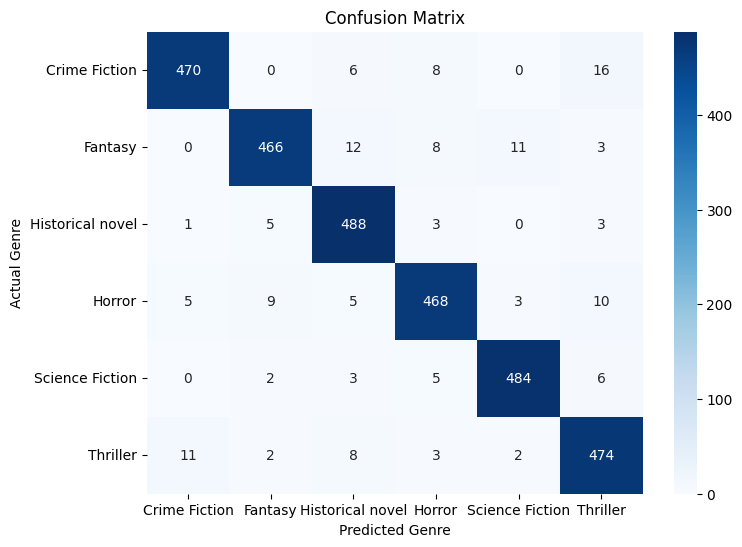

In [147]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(books_with_predictions['genre'], books_with_predictions['predicted_genre'])

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.title('Confusion Matrix')
plt.show()

boucle pour chaque ligne

In [148]:
for i, genre in enumerate(label_encoder.classes_):
    print(f"Label Encoded {i} corresponds to Genre: {genre}")

Label Encoded 0 corresponds to Genre: Crime Fiction
Label Encoded 1 corresponds to Genre: Fantasy
Label Encoded 2 corresponds to Genre: Historical novel
Label Encoded 3 corresponds to Genre: Horror
Label Encoded 4 corresponds to Genre: Science Fiction
Label Encoded 5 corresponds to Genre: Thriller


In [149]:
books

,book_id,book_name,genre,summary,summary2,genre_encoded_txt
0,3248537,Drowned Wednesday,Fantasy,Drowned Wednesday is the first Trustee among ...,drown wednesday first truste among morrow day ...,1
1,27796919,The Lost Hero,Fantasy,"As the book opens, Jason awakens on a school ...",book open jason awaken school bu unabl rememb ...,1
2,3910776,The Eyes of the Overworld,Fantasy,Cugel is easily persuaded by the merchant Fia...,cugel easili persuad merchant fianosth attempt...,1
3,5969644,Magic's Promise,Fantasy,The book opens with Herald-Mage Vanyel return...,book open heraldmag vanyel return countri vald...,1
4,3173445,Taran Wanderer,Fantasy,Taran and Gurgi have returned to Caer Dallben...,taran gurgi return caer dallben follow event t...,1
...,...,...,...,...,...,...
2995,10372180,White Death,Thriller,"A Novel from the NUMA files, A Kurt Austin Ad...",novel numa file kurt austin adventur novel mai...,5
2996,14504372,Venus with Pistol,Thriller,Gilbert Kemp is dealer specializing in antiqu...,gilbert kemp dealer special antiqu gun london ...,5
2997,3617412,Blackwater,Thriller,"""How do you know when you're in too deep? Dav...",know your deep davey alway live shadow older b...,5
2998,11320975,The Rainbow and the Rose,Thriller,The story concerns the life of Johnnie Pascoe...,stori concern life johnni pasco retir commerci...,5


In [150]:
predictions = []

In [151]:
for _, livre in books.iterrows():
    if livre['genre'] == 'Crime Fiction':
        predicted_genre = predict_genre(livre['summary'], model, tokenizer, label_encoder, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        predictions.append(predicted_genre)

In [152]:
len(predictions)

500

In [153]:
correct_predictions = predictions.count('Crime Fiction')
correct_predictions

470

prediction de 'horror" au lieu de 'Crime Fiction'

In [154]:
horror_predictions = predictions.count('Horror')
horror_predictions

8

In [155]:
total_predictions = len(predictions)


In [156]:
print(f"Nombre total de prédictions pour 'Crime Fiction': {total_predictions}")

print(f"Nombre de prédictions correctes pour 'Crime Fiction': {correct_predictions}")

Nombre total de prédictions pour 'Crime Fiction': 500
Nombre de prédictions correctes pour 'Crime Fiction': 470


In [157]:
print(f"accuracy pour 'Crime Fiction': {correct_predictions / total_predictions}")

accuracy pour 'Crime Fiction': 0.94


In [158]:
print(f"nb de faux negatifs pour 'Crime Fiction': {total_predictions- correct_predictions}")

nb de faux negatifs pour 'Crime Fiction': 30




---



---



In [159]:

#affiche les precision recall f1-score
from sklearn.metrics import classification_report
report = classification_report(books_with_predictions['genre'], books_with_predictions['predicted_genre'],target_names=label_encoder.classes_)

print(report)

                  precision    recall  f1-score   support

   Crime Fiction       0.97      0.94      0.95       500
         Fantasy       0.96      0.93      0.95       500
Historical novel       0.93      0.98      0.95       500
          Horror       0.95      0.94      0.94       500
 Science Fiction       0.97      0.97      0.97       500
        Thriller       0.93      0.95      0.94       500

        accuracy                           0.95      3000
       macro avg       0.95      0.95      0.95      3000
    weighted avg       0.95      0.95      0.95      3000



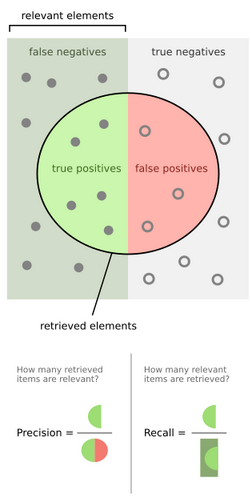

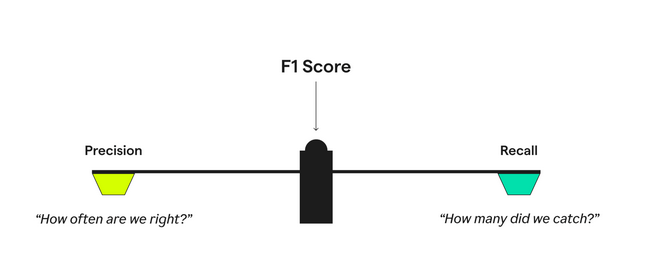

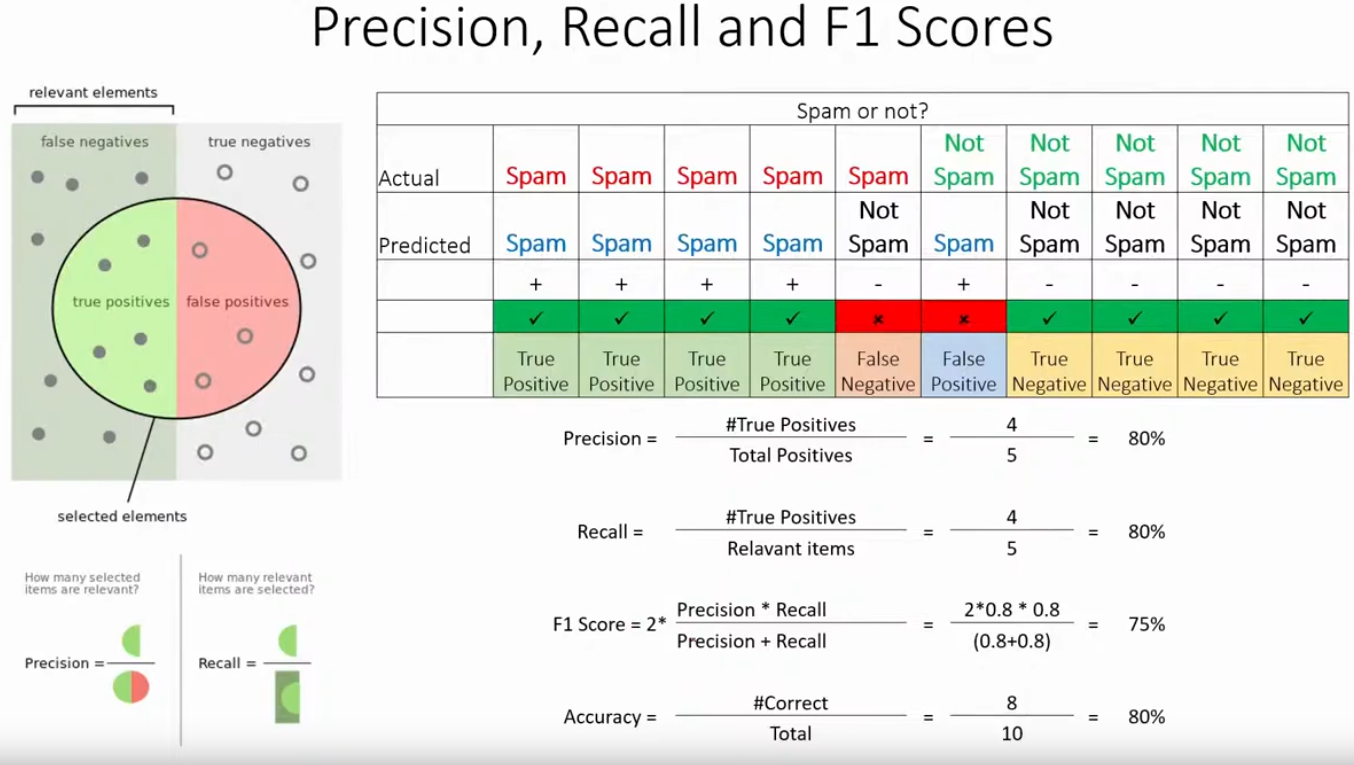



Précision : parmi toutes les prédictions positives du modèle, combien sont vraiment correctes.

Rappel : parmi tous les cas réellement positifs, combien ont été correctement détectés par le modèle.


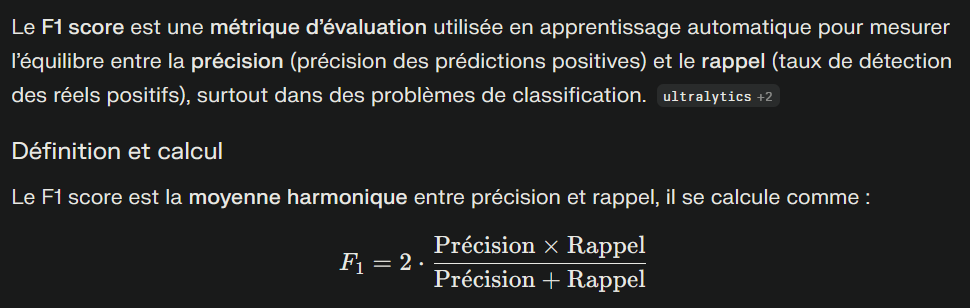

Le F1 score varie entre 0 (mauvaise performance) et 1 (précision et rappel parfaits)
Il est particulièrement utile lorsque les classes sont déséquilibrées (ex : détection de fraudes, maladies rares) car il pénalise les modèles qui négligent soit la précision, soit le rappel.

In [160]:
predictions_complete = []



---



---



In [163]:
# Get prediction probabilities for all classes
def get_all_probabilities(texts):
  model.eval()
  all_probs = []
  # print(texts)
  with torch.no_grad():
    for text in texts:
      print('\n ')
      print( text)

      encoding = tokenizer.encode_plus(
              text,
              add_special_tokens=True,
              max_length=512,
              padding='max_length',
              truncation=True,
              return_attention_mask=True,
              return_tensors='pt'
              )

      input_ids = encoding['input_ids'].to(device)
      attention_mask = encoding['attention_mask'].to(device)

      outputs = model(input_ids=input_ids, attention_mask=attention_mask)
      probs = torch.softmax(outputs.logits, dim=1)
      print(probs)
      all_probs.append(probs.cpu().numpy())
  print(all_probs)
  return np.vstack(all_probs)

In [165]:
y_score = get_all_probabilities(books_with_predictions['summary'])
# y_score

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
tensor([[5.7343e-04, 9.7582e-05, 7.7477e-05, 4.1644e-04, 1.9771e-04, 9.9864e-01]],
       device='cuda:0')

 
 In Capital Crimes, Will Lee finds himself in the middle of a tangled web of intrigue and danger, politics and power. Now at the pinnacle of his career, serving as president of the United States, Lee is faced with a most unusual task-that of marshaling federal law enforcement agencies to catch an assassin who is picking off some of the nation's high-level politicos. When a prominent conservative politician with a shady reputation is expertly killed at his lakeside cabin, authorities can come up with no suspects and even less hard evidence. But then, within days, two other, seemingly isolated deaths-achieved by very different means-are feared linked to the same ruthless murderer. With the help of his CIA director wife, Kate Rule Lee, Will trails the most clever and professional of killers before he can

array([[8.4832392e-04, 6.4260781e-01, 5.5056257e-04, 3.5468602e-01,
        9.9282328e-04, 3.1449756e-04],
       [1.8077837e-04, 9.9766964e-01, 4.2876467e-04, 1.2258925e-03,
        3.8528477e-04, 1.0948399e-04],
       [1.2412330e-04, 9.9852377e-01, 2.2801918e-04, 6.0835702e-04,
        3.7182841e-04, 1.4392691e-04],
       ...,
       [4.1962895e-04, 1.3302907e-04, 1.0127955e-04, 2.7179753e-04,
        2.9610883e-04, 9.9877816e-01],
       [7.0646510e-04, 5.9787842e-05, 1.4195814e-04, 6.5029535e-04,
        2.9824383e-04, 9.9814332e-01],
       [3.8285104e-03, 7.8350655e-05, 3.9712866e-04, 4.8198681e-03,
        3.6479434e-04, 9.9051136e-01]], dtype=float32)

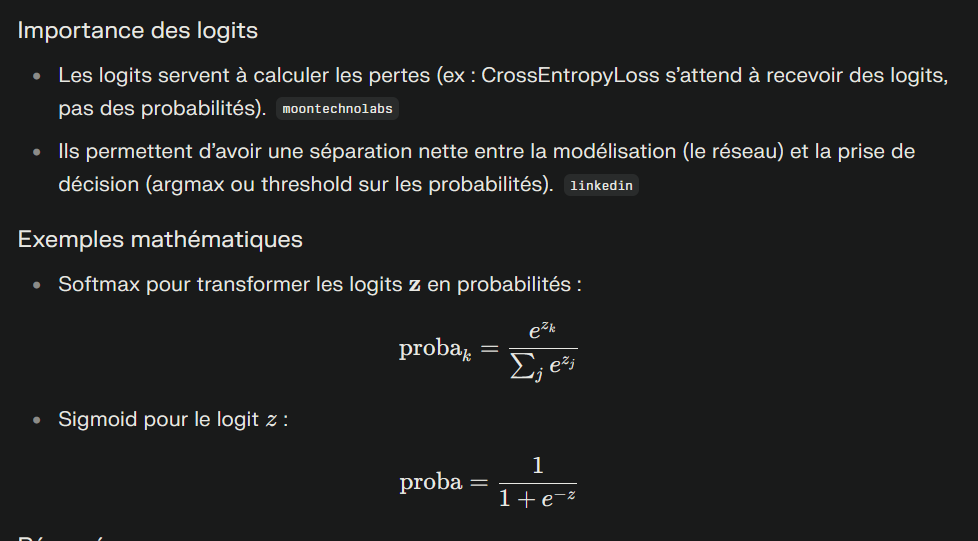

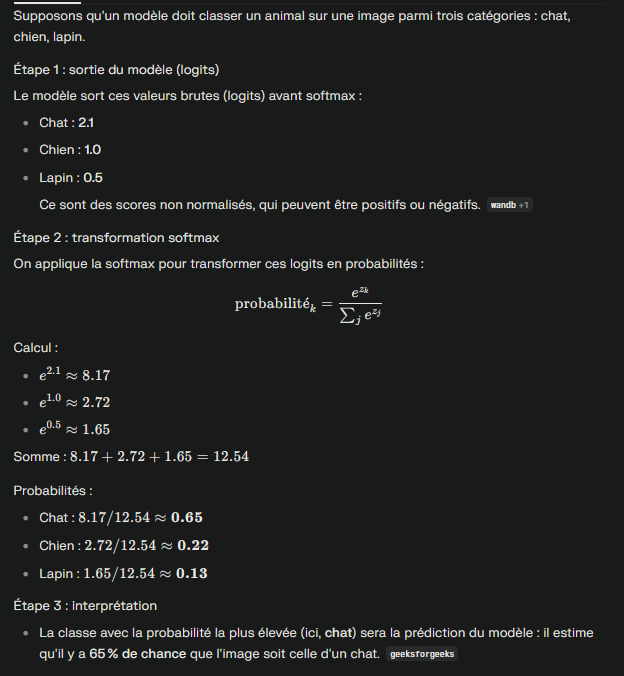

In [166]:
books_with_predictions.head(10)

,book_id,book_name,genre,summary,summary2,genre_encoded_txt,predicted_genre
0,3248537,Drowned Wednesday,Fantasy,Drowned Wednesday is the first Trustee among ...,drown wednesday first truste among morrow day ...,1,Fantasy
1,27796919,The Lost Hero,Fantasy,"As the book opens, Jason awakens on a school ...",book open jason awaken school bu unabl rememb ...,1,Fantasy
2,3910776,The Eyes of the Overworld,Fantasy,Cugel is easily persuaded by the merchant Fia...,cugel easili persuad merchant fianosth attempt...,1,Fantasy
3,5969644,Magic's Promise,Fantasy,The book opens with Herald-Mage Vanyel return...,book open heraldmag vanyel return countri vald...,1,Fantasy
4,3173445,Taran Wanderer,Fantasy,Taran and Gurgi have returned to Caer Dallben...,taran gurgi return caer dallben follow event t...,1,Fantasy
5,19401625,Thendara House,Fantasy,The novel concerns the dwelling of the Darkov...,novel concern dwell darkovan order renunci als...,1,Fantasy
6,6563632,The Thief,Fantasy,"Gen is released from prison by the magus, the...",gen releas prison magu king scholar magu find ...,1,Fantasy
7,8700946,The Sweet Far Thing,Fantasy,The prologue begins with two men who are sear...,prologu begin two men search river london thre...,1,Fantasy
8,6216269,Mistborn: The Final Empire,Fantasy,"In Luthadel, the capital city of the Final Em...",luthadel capit citi final empir vin scrawni st...,1,Fantasy
9,10933407,The Sorcerer's Ship,Fantasy,A man named Gene finds himself cast into a ne...,man name gene find cast new world power godlik...,1,Fantasy


In [167]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [173]:
true_labels = books_with_predictions['genre']
predicted_labels = books_with_predictions['predicted_genre']


# Prepare data for ROC curves
y_test_bin = label_binarize(true_labels, classes=label_encoder.classes_)
n_classes = len(label_encoder.classes_)

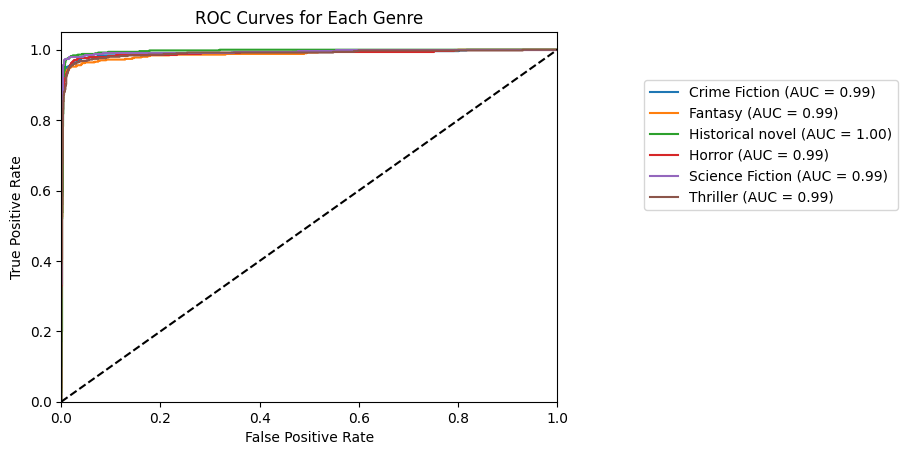

In [174]:
# Plot ROC curve for each class
for i in range(n_classes):
  fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Genre')
plt.legend(loc="lower right", bbox_to_anchor=(1.7, 0.5))
plt.show()